# 🌈 Análise tempo-frequência (espectrograma)
por: **Iury Coelho**

A Transformada de Fourier (notebooks 03 e 04) responde *quais* frequências
existem num sinal — mas **não diz quando** elas acontecem. Para sinais que
**mudam ao longo do tempo** (a fala, um motor acelerando, a respiração de uma
pessoa que se agita), isso é uma limitação séria.

A **STFT** (*Short-Time Fourier Transform*) resolve isso: ela aplica a FFT em
**janelas curtas que deslizam** pelo sinal, produzindo um mapa de **frequência
× tempo** — o **espectrograma**. É uma das ferramentas centrais do
sensoriamento por rádio (ex.: o RuView observa a respiração e o movimento
*evoluírem* no tempo).

#### Conteúdo
* [1. A FFT perde o tempo](#1)
* [2. A STFT: janela deslizante](#2)
* [3. Quando o "quando" importa](#3)
* [4. Trade-off tempo × frequência](#4)
* [5. Sensing: respiração que muda de ritmo](#5)
* [6. Da simulação ao mundo real](#6)
* [7. Exercício](#7)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as ss
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (9, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def espectro(x, fs):
    X = np.abs(np.fft.rfft(x)) / len(x) * 2
    f = np.fft.rfftfreq(len(x), 1/fs)
    return f, X

def desenha_espectrograma(ax, x, fs, nperseg=256, noverlap=None, fmax=None):
    if noverlap is None:
        noverlap = nperseg * 3 // 4
    f, t, Sxx = ss.spectrogram(x, fs, nperseg=nperseg, noverlap=noverlap)
    ax.pcolormesh(t, f, 10*np.log10(Sxx + 1e-12), shading="auto", cmap="magma")
    if fmax:
        ax.set_ylim(0, fmax)
    ax.set_xlabel("tempo [s]"); ax.set_ylabel("frequência [Hz]")
    return f, t, Sxx

<a id="1"></a>
## 1. A FFT perde o tempo

Considere um **chirp**: um tom que varre de 100 Hz a 1500 Hz em 3 segundos.
A FFT mostra que *todas* essas frequências estão presentes — mas embaralhadas,
sem dizer que elas aparecem **em sequência**.

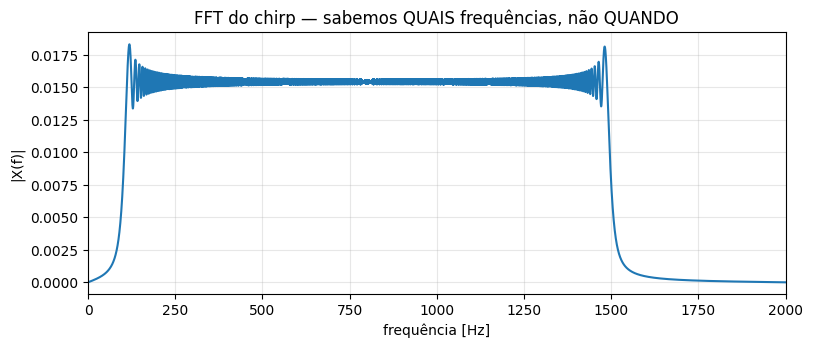

In [2]:
fs = 4000
dur = 3.0
t = np.linspace(0, dur, int(fs*dur), endpoint=False)
chirp = ss.chirp(t, f0=100, f1=1500, t1=dur, method="linear")

f, X = espectro(chirp, fs)
plt.plot(f, X)
plt.xlim(0, 2000)
plt.title("FFT do chirp — sabemos QUAIS frequências, não QUANDO")
plt.xlabel("frequência [Hz]"); plt.ylabel("|X(f)|"); plt.show()

<a id="2"></a>
## 2. A STFT revela a evolução

O mesmo chirp no **espectrograma**: agora a varredura aparece como uma **linha
diagonal subindo** — a frequência crescendo com o tempo. É exatamente a
informação que a FFT tinha jogado fora. (E dá para **ouvir** a subida.)

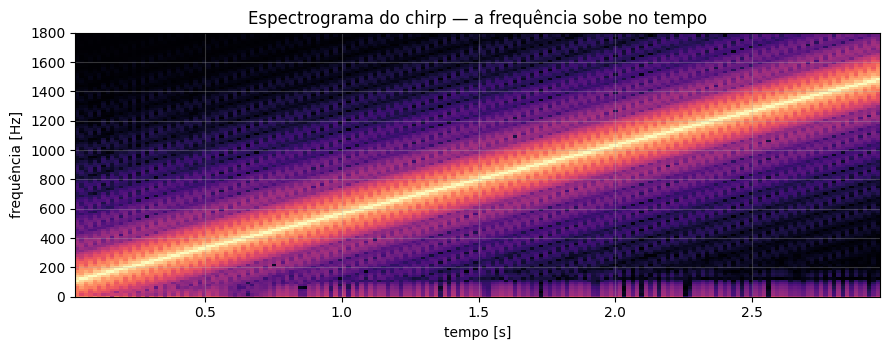

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.6))
desenha_espectrograma(ax, chirp, fs, nperseg=256, fmax=1800)
ax.set_title("Espectrograma do chirp — a frequência sobe no tempo")
plt.tight_layout(); plt.show()

display(Audio(chirp, rate=fs))

<a id="3"></a>
## 3. Quando o "quando" importa

Dois tons que tocam **em momentos diferentes** (primeiro 700 Hz, depois 1400 Hz)
produzem uma FFT idêntica à de dois tons tocando **juntos**: dois picos, sem
ordem. O espectrograma distingue na hora.

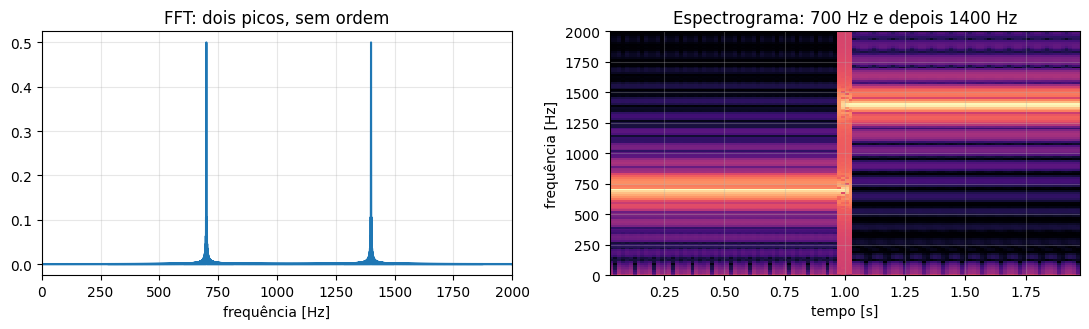

In [4]:
fs = 4000
t = np.linspace(0, 2, 2*fs, endpoint=False)
seq = np.where(t < 1.0, np.sin(2*np.pi*700*t), np.sin(2*np.pi*1400*t))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
f, X = espectro(seq, fs)
a1.plot(f, X); a1.set_xlim(0, 2000)
a1.set_title("FFT: dois picos, sem ordem"); a1.set_xlabel("frequência [Hz]")
desenha_espectrograma(a2, seq, fs, nperseg=256, fmax=2000)
a2.set_title("Espectrograma: 700 Hz e depois 1400 Hz")
plt.tight_layout(); plt.show()

<a id="4"></a>
## 4. Trade-off tempo × frequência

Não dá para ter tudo: uma **janela curta** localiza bem os eventos no **tempo**,
mas borra as **frequências**; uma **janela longa** separa frequências próximas,
mas borra os eventos no tempo. É o **princípio da incerteza** do processamento
de sinais.

Teste: dois tons próximos (1000 e 1100 Hz) com um **clique** no meio.

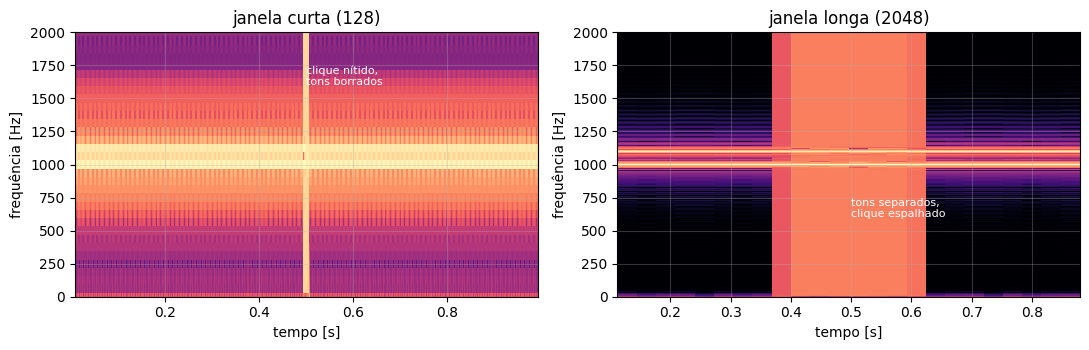

In [5]:
fs = 8000
t = np.linspace(0, 1, fs, endpoint=False)
sig = np.sin(2*np.pi*1000*t) + np.sin(2*np.pi*1100*t)
sig[fs//2] += 30.0                       # um clique (transiente) no meio

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, nperseg, rotulo in [(axs[0], 128, "janela curta (128)"),
                            (axs[1], 2048, "janela longa (2048)")]:
    desenha_espectrograma(ax, sig, fs, nperseg=nperseg,
                          noverlap=nperseg*7//8, fmax=2000)
    ax.set_title(rotulo)
axs[0].annotate("clique nítido,\ntons borrados", (0.5, 1600), color="w", fontsize=8)
axs[1].annotate("tons separados,\nclique espalhado", (0.5, 600), color="w", fontsize=8)
plt.tight_layout(); plt.show()

<a id="5"></a>
## 5. Sensing: respiração que muda de ritmo

Aqui está o elo com o RuView. Uma pessoa começa respirando devagar (12/min) e
**acelera** até 24/min ao longo de 2 minutos — como se estivesse se exercitando.
A FFT daria só uma faixa borrada; o espectrograma mostra a **frequência da
respiração subindo** ao vivo.

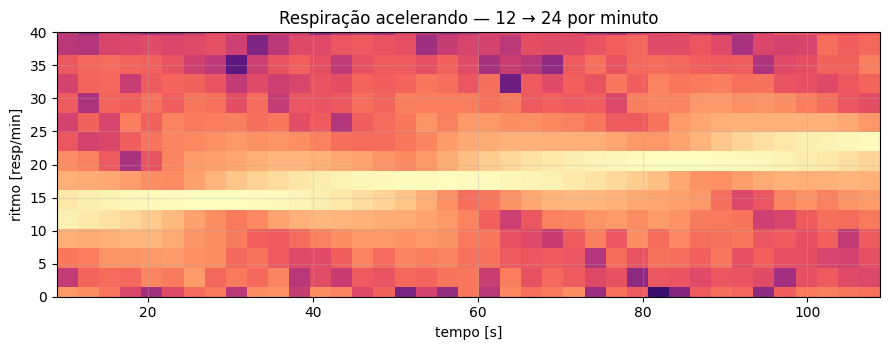

In [6]:
fs = 50.0
dur = 120.0
t = np.arange(0, dur, 1/fs)

# frequencia de respiracao sobe de 12/min (0.2 Hz) para 24/min (0.4 Hz)
f_resp = (12 + 12*t/dur) / 60.0
fase = 2*np.pi*np.cumsum(f_resp)/fs
rng = np.random.default_rng(0)
sinal = np.sin(fase) + 0.3*rng.standard_normal(len(t))

fig, ax = plt.subplots(figsize=(9, 3.6))
f, tt, Sxx = ss.spectrogram(sinal, fs, nperseg=1024, noverlap=896)
ax.pcolormesh(tt, f*60, 10*np.log10(Sxx + 1e-12), shading="auto", cmap="magma")
ax.set_ylim(0, 40)
ax.set_title("Respiração acelerando — 12 → 24 por minuto")
ax.set_xlabel("tempo [s]"); ax.set_ylabel("ritmo [resp/min]")
plt.tight_layout(); plt.show()

<a id="6"></a>
## 6. Da simulação ao mundo real

Num sistema real de sensoriamento por rádio, o espectrograma do CSI revela a
**dinâmica**: a faixa de respiração, picos de movimento (passos, gestos), e
**assinaturas de atividade** que mudam com o tempo. É a base para classificar
"parado × andando × caindo".

> ⚠️ Didático. A medição real envolve muito mais ruído, múltiplos caminhos e
> etapas adicionais (fase, múltiplas antenas, ML).

A STFT é a ponte entre "qual frequência" (Fourier) e "o que está acontecendo
agora" (sensing). 🚀

<a id="7"></a>
## 7. Exercício

__Exercício__ — No espectrograma da respiração (seção 5), experimente
`nperseg = 256` e depois `nperseg = 2048`. O que acontece com a nitidez da linha
de respiração e com a suavidade da sua *subida* no tempo? Relacione com o
trade-off da seção 4.

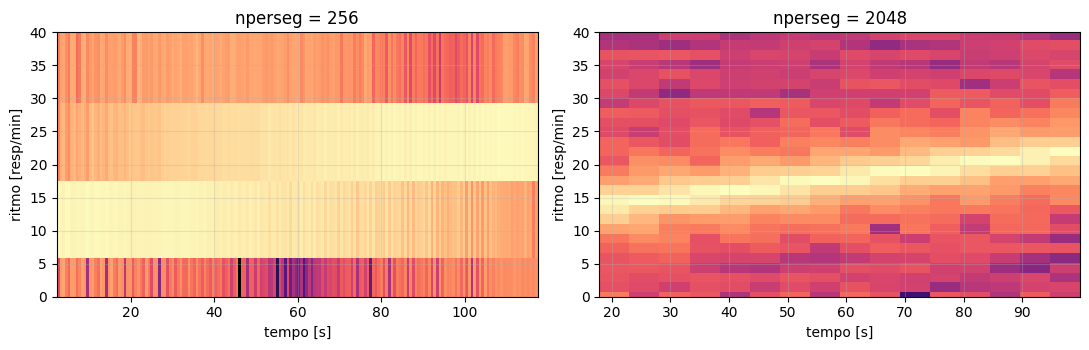

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, nperseg in [(axs[0], 256), (axs[1], 2048)]:
    f, tt, Sxx = ss.spectrogram(sinal, fs, nperseg=nperseg, noverlap=nperseg*7//8)
    ax.pcolormesh(tt, f*60, 10*np.log10(Sxx + 1e-12), shading="auto", cmap="magma")
    ax.set_ylim(0, 40); ax.set_title(f"nperseg = {nperseg}")
    ax.set_xlabel("tempo [s]"); ax.set_ylabel("ritmo [resp/min]")
plt.tight_layout(); plt.show()

__Resposta__: com `nperseg = 256` (janela ~5 s) a linha acompanha bem a *subida*
no tempo, mas fica **grossa/borrada** em frequência. Com `nperseg = 2048`
(janela ~41 s) a linha fica **fina** em frequência, porém "escadeada" no tempo —
a janela longa mistura instantes em que o ritmo já mudou. É o mesmo trade-off da
seção 4, agora na faixa da respiração.

---
<br>[⬆ volte ao topo](#Conteúdo)